In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import numpy as np

In [42]:
data=pd.read_csv(r"C:\Users\LENOVO\Downloads\diabetes.csv",encoding='latin')
data.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [43]:
data.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

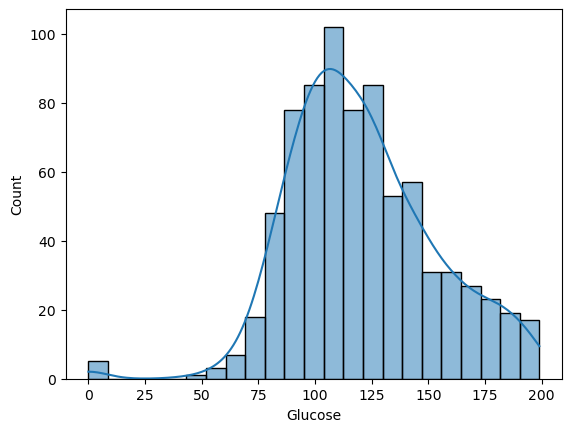

In [44]:
sns.histplot(data["Glucose"],kde=True)
plt.show()

In [57]:
q1=data["Glucose"].quantile(0.25)
q3=data["Glucose"].quantile(0.75)
iqr=q3-q1

In [58]:
min_r=q1-(1.5*iqr)
max_r=q3+(1.5*iqr)
min_r,max_r

(np.float64(37.125), np.float64(202.125))

In [59]:
data=data[data["Glucose"]<=max_r]

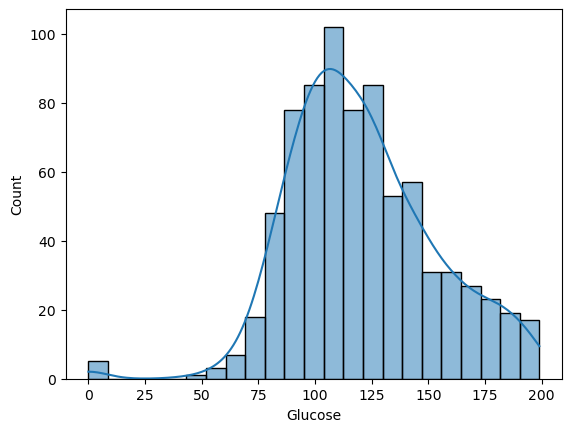

In [60]:
sns.histplot(data["Glucose"],kde=True)
plt.show()

In [61]:
from sklearn.preprocessing import FunctionTransformer

In [62]:
ft=FunctionTransformer(func=np.log1p)

In [63]:
ft.fit(data[["Glucose"]])

,func,<ufunc 'log1p'>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


In [64]:
data["Glucose_tf"]=ft.transform(data[["Glucose"]])

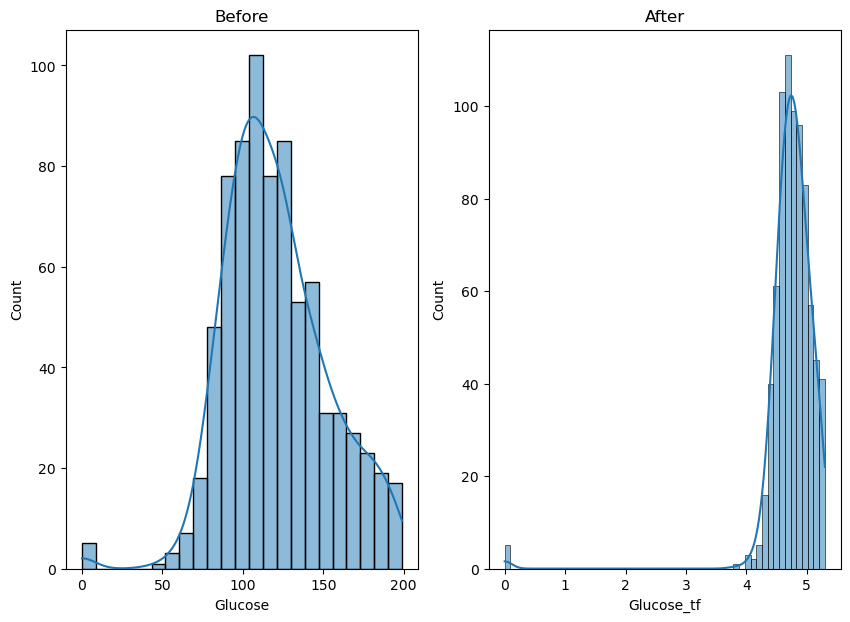

In [53]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
sns.histplot(data["Glucose"],kde=True)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(data["Glucose_tf"],kde=True)
plt.title("After")

plt.show()